# 4.0 FER2013 Multiclass Facial Expression EDA

Purpose:
- Validate the FER2013 dataset
- Build an image manifest
- Inspect class balance
- Inspect split structure
- Identify preprocessing issues

Project relevance:
FER2013 supports the visual modality by testing multiclass facial expression classification, complementing the binary stroke-face classifier.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    FER2013_DATA_DIR,
    FER2013_INTERIM_MANIFEST_PATH,
    FIGURES_DIR,
)
from rural_stroke_assist.preprocessing.fer2013 import (
    build_fer2013_manifest,
    validate_fer2013_manifest,
)

In [2]:
print(FER2013_DATA_DIR)
print("Exists:", FER2013_DATA_DIR.exists())

for path in FER2013_DATA_DIR.iterdir():
    print(path.name)

C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\raw\fer2013
Exists: True
test
train


In [3]:
fer_df = build_fer2013_manifest(FER2013_DATA_DIR)

fer_df.head()

,path,file_name,class_label,label_encoded,split,extension,readable,width,height
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,PrivateTest_10131363.jpg,angry,0,test,.jpg,True,48,48
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,PrivateTest_10304478.jpg,angry,0,test,.jpg,True,48,48
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,PrivateTest_1054527.jpg,angry,0,test,.jpg,True,48,48
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,PrivateTest_10590091.jpg,angry,0,test,.jpg,True,48,48
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,PrivateTest_1109992.jpg,angry,0,test,.jpg,True,48,48


In [4]:
validate_fer2013_manifest(fer_df)

{'total_images': 35887,
 'readable_images': 35887,
 'unknown_labels': 0,
 'unknown_splits': 0,
 'num_classes': 7,
 'splits': ['test', 'train']}

In [5]:
fer_df.shape

(35887, 9)

In [6]:
fer_df["split"].value_counts()

split
train    28709
test      7178
Name: count, dtype: int64

In [7]:
class_balance = (
    fer_df["class_label"]
    .value_counts()
    .rename_axis("class_label")
    .reset_index(name="count")
)

class_balance["percentage"] = (
    class_balance["count"] / class_balance["count"].sum() * 100
).round(2)

class_balance

,class_label,count,percentage
0,happy,8989,25.05
1,neutral,6198,17.27
2,sad,6077,16.93
3,fear,5121,14.27
4,angry,4953,13.80
5,surprise,4002,11.15
6,disgust,547,1.52


In [8]:
split_class_balance = (
    fer_df.groupby(["split", "class_label"])
    .size()
    .rename("count")
    .reset_index()
)

split_class_balance

,split,class_label,count
0,test,angry,958
1,test,disgust,111
2,test,fear,1024
3,test,happy,1774
4,test,neutral,1233
5,test,sad,1247
6,test,surprise,831
7,train,angry,3995
8,train,disgust,436
9,train,fear,4097


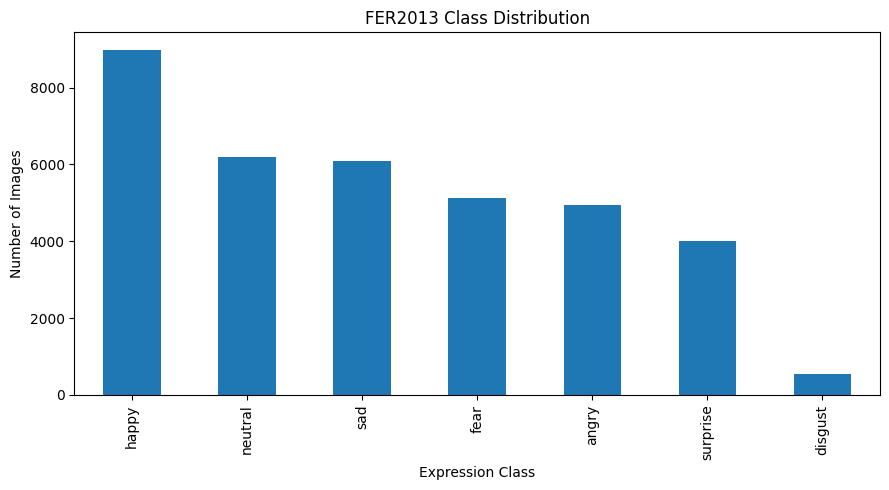

In [9]:
fer_df["class_label"].value_counts().plot(
    kind="bar",
    title="FER2013 Class Distribution",
    figsize=(9, 5),
)

plt.xlabel("Expression Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [10]:
output_path = FIGURES_DIR / "fer2013_class_distribution.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

fer_df["class_label"].value_counts().plot(
    kind="bar",
    title="FER2013 Class Distribution",
    figsize=(9, 5),
)

plt.xlabel("Expression Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(output_path)
plt.close()

output_path

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/reports/figures/fer2013_class_distribution.png')

In [11]:
fer_df[["width", "height"]].describe()

,width,height
count,35887.0,35887.0
mean,48.0,48.0
std,0.0,0.0
min,48.0,48.0
25%,48.0,48.0
50%,48.0,48.0
75%,48.0,48.0
max,48.0,48.0


In [12]:
fer_df[fer_df["readable"] == False].head()

,path,file_name,class_label,label_encoded,split,extension,readable,width,height


In [13]:
fer_df[fer_df["class_label"] == "unknown"].head()

,path,file_name,class_label,label_encoded,split,extension,readable,width,height


In [14]:
fer_df[fer_df["split"] == "unknown"].head()

,path,file_name,class_label,label_encoded,split,extension,readable,width,height


In [15]:
FER2013_INTERIM_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)

fer_df.to_csv(FER2013_INTERIM_MANIFEST_PATH, index=False)

FER2013_INTERIM_MANIFEST_PATH

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/interim/fer2013_image_manifest.csv')

## FER2013 Preprocessing Issues

Observed issues:
1. Images are low-resolution 48x48 grayscale faces.
2. Classes are imbalanced, especially the `disgust` class.
3. Some expressions may be visually ambiguous.
4. Labels are emotion labels, not clinical stroke labels.
5. The dataset is useful for testing multiclass facial-expression recognition, not stroke diagnosis.

Planned approach:
- Use train/test structure from the dataset.
- Create validation split from training data.
- Use training-only augmentation.
- Evaluate with macro F1 in addition to accuracy because of class imbalance.